# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pankaj1281/flyrank_ml_internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research question

Can content and search-performance signals be used to identify content that may be declining and prioritize pages for human review?

### Decision supported

The analysis supports a content team's decision about which pages should be reviewed first for possible refresh, monitoring, or further investigation.

The output is decision support based on observed data patterns, not a causal recommendation that changing a page will improve traffic.

In [17]:
print("Research question: identify potentially declining content.")
print("Decision: prioritize pages for human review.")

Research question: identify potentially declining content.
Decision: prioritize pages for human review.


## 2. Data

This analysis uses the FlyRank starter dataset containing 30,000 pseudonymized content items and 44 columns.

The data contains 90-day content and search-performance measures together with content characteristics and freshness signals.

The analysis excludes identifiers such as `content_id` and `client_id` from model features. Label-derived fields such as `trend_direction` and `trend_pct` are also excluded because they are used to define the target.

No client names, domains, private queries, credentials, or raw private exports are included in the analysis.

In [18]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Date/window note: starter dataset contains trailing 90-day metrics.")
print("Excluded from model features:")
print("- content_id")
print("- client_id")
print("- trend_direction")
print("- trend_pct")

Rows: 30000
Columns: 45
Date/window note: starter dataset contains trailing 90-day metrics.
Excluded from model features:
- content_id
- client_id
- trend_direction
- trend_pct


## 3. Methodology

The target is `is_declining_label`, defined as whether `trend_direction` is equal to `down`.

The model uses search-performance, content, freshness, and engagement-related signals available in the dataset. Identifiers and label-derived fields are excluded from the feature set.

A Random Forest classifier is used because it can capture nonlinear relationships between multiple signals. The baseline is a majority-class classifier.

Validation uses a client-grouped split: 25 clients are used for training and 7 unseen clients are used for testing, with zero clients shared between the two sets.

Leakage checks exclude `trend_direction`, `trend_pct`, and the target from model features. `content_id` and `client_id` are used only for identification or grouping.

In [19]:
print("Model: Random Forest")
print("Label: is_declining_label")
print("Train clients:", 25)
print("Test clients:", 7)
print("Shared clients:", 0)
print("Leakage fields used as features: 0")

Model: Random Forest
Label: is_declining_label
Train clients: 25
Test clients: 7
Shared clients: 0
Leakage fields used as features: 0


## 4. Results (vs baseline)

The Random Forest was evaluated on the same client-grouped test set as the baseline. The model measured higher accuracy, precision, recall, and F1 than the majority-class baseline.

The F1 score increased from 0.676 for the baseline to 0.827 for the Random Forest on the held-out clients. This is a measured improvement on this test split and should not be treated as a guarantee of future performance.

In [20]:
comparison = pd.DataFrame(
    {
        "accuracy": [0.510952, 0.814052],
        "precision": [0.510952, 0.788201],
        "recall": [1.000000, 0.869800],
        "f1": [0.676332, 0.826993]
    },
    index=["Baseline", "Random Forest"]
)

comparison

,accuracy,precision,recall,f1
Baseline,0.510952,0.510952,1.0000,0.676332
Random Forest,0.814052,0.788201,0.8698,0.826993


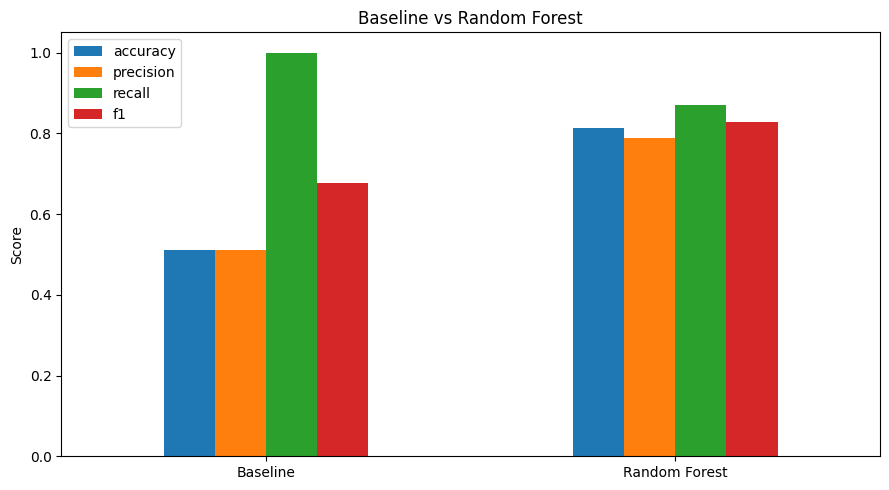

In [21]:
import matplotlib.pyplot as plt

comparison[["accuracy", "precision", "recall", "f1"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Baseline vs Random Forest")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Limitations

This analysis cannot establish that refreshing content causes traffic or ranking improvements.

The results are measured on a particular held-out client split and may not generalize to every future client or time period.

The starter dataset contains an unbalanced set of content histories, and some signals have substantial missingness or heavy-tailed distributions.

The recommendations should therefore be treated as directional decision support and reviewed by a human before action.

In [22]:
limitations = [
    "No causal refresh-impact claim",
    "Evaluation is based on a held-out client split",
    "Results may not generalize to all future data",
    "Human review is required"
]

for item in limitations:
    print("-", item)

- No causal refresh-impact claim
- Evaluation is based on a held-out client split
- Results may not generalize to all future data
- Human review is required


## 6. Ranked recommendations

The action playbook ranks content using model predictions and assigns human-readable reason codes from observed signals.

Pages with stronger predicted decline risk are prioritized for review. Reason codes such as stale content, low CTR, high impressions, and low search position help reviewers understand why a page was surfaced.

The ranking is intended for human review and does not automatically trigger publishing, deletion, rewriting, or other content changes.

In [23]:
from sklearn.model_selection import GroupShuffleSplit

df["is_declining_label"] = (
    df["trend_direction"] == "down"
).astype(int)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(df, groups=df["client_id"])
)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Train rows: 23837
Test rows: 6163


In [24]:
numeric_features = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d",
    "users_90d", "engaged_sessions_90d", "ai_sessions_90d",
    "days_with_impressions", "days_with_sessions",
    "impressions_last_30d", "clicks_last_30d", "sessions_last_30d",
    "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d",
    "content_age_days", "days_since_last_update", "ctr", "avg_position",
    "engagement_rate", "scroll_rate", "ai_traffic_pct"
]

categorical_features = [
    "competition_level", "content_type", "main_intent",
    "age_tier", "freshness_tier", "word_count_tier",
    "char_count_tier", "impression_tier", "position_tier"
]

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

X_train = train_df[numeric_features + categorical_features]
y_train = train_df["is_declining_label"]

X_test = test_df[numeric_features + categorical_features]
y_test = test_df["is_declining_label"]

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

model_pipeline.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [26]:
import numpy as np

action_queue = test_df.copy()

action_queue["decline_probability"] = (
    model_pipeline.predict_proba(X_test)[:, 1]
)

def reason_code(row):
    reasons = []

    if row["days_since_last_update"] >= 90:
        reasons.append("STALE_CONTENT")

    if row["ctr"] <= 0.1:
        reasons.append("LOW_CTR")

    if row["impressions_90d"] >= df["impressions_90d"].quantile(0.75):
        reasons.append("HIGH_IMPRESSIONS")

    if row["avg_position"] > 20:
        reasons.append("LOW_POSITION")

    return ";".join(reasons) if reasons else "MODEL_SIGNAL"

action_queue["reason_code"] = action_queue.apply(
    reason_code,
    axis=1
)

action_queue["action"] = np.where(
    action_queue["decline_probability"] >= 0.70,
    "Refresh Immediately",
    np.where(
        action_queue["decline_probability"] >= 0.50,
        "Review",
        "Monitor"
    )
)

action_queue = action_queue.sort_values(
    "decline_probability",
    ascending=False
)

action_queue["rank"] = range(1, len(action_queue) + 1)

print("Action queue created:", len(action_queue))

Action queue created: 6163


In [27]:
ranked_recommendations = action_queue[
    [
        "rank",
        "content_id",
        "decline_probability",
        "action",
        "reason_code"
    ]
].head(20)

ranked_recommendations

,rank,content_id,decline_probability,action,reason_code
5410,1,content_53285c7434ac,0.980,Refresh Immediately,LOW_CTR
29681,2,content_9e8671965fff,0.980,Refresh Immediately,LOW_CTR
18822,3,content_b23d650634c6,0.975,Refresh Immediately,LOW_CTR
2139,4,content_41538bdb1b1e,0.975,Refresh Immediately,LOW_CTR
3329,5,content_eb3b2c3bbc34,0.970,Refresh Immediately,LOW_CTR
2043,6,content_769c5991e2f6,0.970,Refresh Immediately,MODEL_SIGNAL
18949,7,content_7cd9b5db3ea1,0.970,Refresh Immediately,MODEL_SIGNAL
17707,8,content_f6bf66378677,0.970,Refresh Immediately,LOW_CTR
14343,9,content_9ac61c04930e,0.965,Refresh Immediately,STALE_CONTENT
23480,10,content_9234f5075e7a,0.965,Refresh Immediately,MODEL_SIGNAL


## 7. Artifacts the paper embeds

The paper uses the model-versus-baseline comparison and the ranked recommendation queue as its main evidence artifacts. These outputs provide the measured model comparison and a practical ranked action view.

In [28]:
import os

OUTPUT_DIR = "/content/flyrank_ml_internship/work/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

comparison.to_csv(
    f"{OUTPUT_DIR}/model_vs_baseline.csv"
)

ranked_recommendations.to_csv(
    f"{OUTPUT_DIR}/ranked_recommendations.csv",
    index=False
)

print("Artifacts written:")
print("- model_vs_baseline.csv")
print("- ranked_recommendations.csv")

Artifacts written:
- model_vs_baseline.csv
- ranked_recommendations.csv


## 5-Minute Demo Outline

1. Introduce the research question: identifying potentially declining content for human review.
2. Explain the dataset, target, features, and leakage controls.
3. Explain the client-grouped validation with 25 training clients and 7 held-out clients.
4. Compare the Random Forest with the majority-class baseline.
5. Show the ranked recommendations and explain how content teams can use them for decision support.

## Social-Post Cut

Built a Search Intelligence workflow using FlyRank data to identify potentially declining content. I compared a Random Forest with a baseline using a client-grouped holdout and converted the results into ranked content-review recommendations. The model measured an F1 of 0.827 versus 0.676 for the baseline on held-out clients.

## Employer-Facing Summary

I built an end-to-end search-intelligence workflow covering data contracts, leakage checks, signal auditing, grouped validation, modeling, and ranked recommendations. A Random Forest measured an F1 score of 0.827 versus 0.676 for the baseline on held-out clients. The workflow emphasizes reproducibility, honest validation, and human-centered decision support.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
